In [1]:
#r "nuget: ScottPlot, 5.0.*"


Installed Packages ScottPlot, 5.0.56

Loading extensions from `/home/artem/.nuget/packages/skiasharp/2.88.9/interactive-extensions/dotnet/SkiaSharp.DotNet.Interactive.dll`

Installed Packages skiasharp.nativeassets.linux.nodependencies, 2.88.9


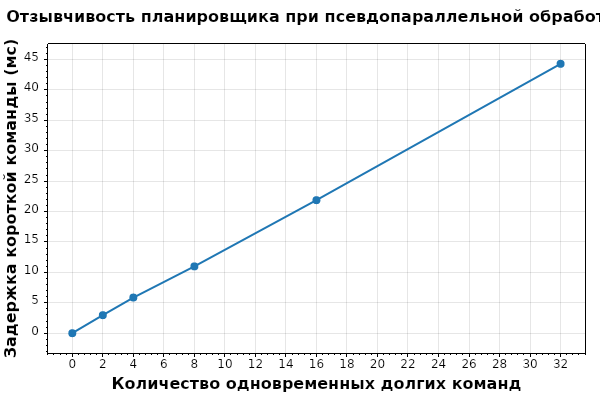

In [2]:
#r "/home/artem/учёбаб/practice_2026/task17/bin/Debug/net10.0/task17.dll"

#r "nuget: SkiaSharp.NativeAssets.Linux.NoDependencies"

using System;
using System.Diagnostics;
using System.IO;
using System.Linq;
using System.Threading;
using ScottPlot;
using task17;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) =>
    w.Write(((ScottPlot.Plot)p).GetPngHtml(600, 400)), HtmlFormatter.MimeType);

ScottPlot.Fonts.Default = "DejaVu Sans";

int iterations = 10;
Stopwatch sw = new Stopwatch();

double Median(double[] values)
{
    var sorted = values.OrderBy(v => v).ToArray();
    int mid = sorted.Length / 2;
    return sorted.Length % 2 == 0
        ? (sorted[mid - 1] + sorted[mid]) / 2.0
        : sorted[mid];
}

public class TimestampedShortCommand : ICommand
{
    public long ExecutedAtTicks { get; private set; } = -1;
    public void Execute() => ExecutedAtTicks = DateTime.UtcNow.Ticks;
}

public class SteppedLongCommand : ILongRunningCommand
{
    private readonly int _totalSlices;
    private int _done;
    public SteppedLongCommand(int totalSlices) => _totalSlices = totalSlices;
    public bool IsCompleted => _done >= _totalSlices;
    public void Execute() { _done++; Thread.Sleep(1); }
}

double MeasureLatencyMs(int longCommandCount)
{
    var server = new ServerThread();
    long enqueuedAt = DateTime.UtcNow.Ticks;

    for (int k = 0; k < longCommandCount; k++)
        server.Enqueue(new SteppedLongCommand(totalSlices: 20));

    var shortCmd = new TimestampedShortCommand();
    server.Enqueue(shortCmd);
    server.Enqueue(new SoftStop(server));
    server.Join();

    return TimeSpan.FromTicks(shortCmd.ExecutedAtTicks - enqueuedAt).TotalMilliseconds;
}

int[] longCommandCounts = { 0, 2, 4, 8, 16, 32 };
double[] avgLatencies = new double[longCommandCounts.Length];

for (int i = 0; i < longCommandCounts.Length; i++)
{
    double[] samples = new double[iterations];
    for (int j = 0; j < iterations; j++)
    {
        samples[j] = MeasureLatencyMs(longCommandCounts[i]);
    }
    avgLatencies[i] = Median(samples);
}

string filePath = "results.txt";
using (StreamWriter writer = new StreamWriter(filePath))
{
    writer.WriteLine("Задержка выполнения короткой команды в зависимости от числа одновременных долгих команд:");
    for (int i = 0; i < longCommandCounts.Length; i++)
        writer.WriteLine($"Долгих команд: {longCommandCounts[i]} -> медианная задержка: {avgLatencies[i]:F2} мс");
}

var plt = new ScottPlot.Plot();
var scatter = plt.Add.Scatter(longCommandCounts.Select(n => (double)n).ToArray(), avgLatencies);
scatter.MarkerSize = 8;
scatter.LineWidth = 2;
plt.XLabel("Количество одновременных долгих команд");
plt.YLabel("Задержка короткой команды (мс)");
plt.Title("Отзывчивость планировщика при псевдопараллельной обработке");

plt.SavePng("plot.png", 800, 600);

plt